### Correlação de potências - Olimpíadas e Paralimpíadas  

**A Pergunta:** Os países que dominam as Olimpíadas são os mesmos que dominam as Paralimpíadas?  

A Comparação: #botar algo aqui depois...

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [27]:
df_olimpiadas = pd.read_csv('olimpiadas_medalhas_arrumado.csv', encoding='utf-8')
display(df_olimpiadas.head())

df_paralimpiadas = pd.read_csv('paralimpiada_medalhas_arrumado.csv', encoding='utf-8')
display(df_paralimpiadas.head())

display(df_olimpiadas.info())
display(df_paralimpiadas.info())

,No.,País,Jogos,Ouro,Prata,Bronze,Total,NOC
0,1,Estados Unidos,29,1101,880,781,2762,USA
1,2,União Soviética,9,395,319,296,1010,URS
2,3,China,12,302,227,197,726,CHN
3,4,Grã-Bretanha,30,300,338,344,982,GBR
4,5,França,30,240,280,298,818,FRA


,País,Ouro,Prata,Bronze,Total,NOC
0,Estados Unidos,808,736,739,2283,USA
1,Grã-Bretanha,667,621,626,1914,GBR
2,Alemanha,521,529,500,1550,GER
3,China,535,400,302,1237,CHN
4,Austrália,389,422,394,1205,AUS


<class 'pandas.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   No.     155 non-null    int64
 1   País    155 non-null    str  
 2   Jogos   155 non-null    int64
 3   Ouro    155 non-null    int64
 4   Prata   155 non-null    int64
 5   Bronze  155 non-null    int64
 6   Total   155 non-null    int64
 7   NOC     154 non-null    str  
dtypes: int64(6), str(2)
memory usage: 9.8 KB


None

<class 'pandas.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   País    129 non-null    str  
 1   Ouro    129 non-null    int64
 2   Prata   129 non-null    int64
 3   Bronze  129 non-null    int64
 4   Total   129 non-null    int64
 5   NOC     129 non-null    str  
dtypes: int64(4), str(2)
memory usage: 6.2 KB


None

In [28]:
df_olimpiadas["Total_calc"] = df_olimpiadas['Ouro'] + df_olimpiadas['Prata'] + df_olimpiadas['Bronze']
inconsistente = df_olimpiadas[df_olimpiadas['Total'] != df_olimpiadas['Total_calc']]

print(inconsistente)

Empty DataFrame
Columns: [No., País, Jogos, Ouro, Prata, Bronze, Total, NOC, Total_calc]
Index: []


In [29]:
df_paralimpiadas["Total_calc"] = df_paralimpiadas['Ouro'] + df_paralimpiadas['Prata'] + df_paralimpiadas['Bronze']
inconsistente = df_paralimpiadas[df_paralimpiadas['Total'] != df_paralimpiadas['Total_calc']]

print(inconsistente)

                País  Ouro  Prata  Bronze  Total  NOC  Total_calc
6             Canadá   400    340     346   1080  CAN        1086
10            Itália   181    224     226    665  ITA         631
17     Coreia do Sul   128    126     121    365  KOR         375
22         Dinamarca    96     83     106    282  DEN         285
28         Argentina    31     66      69    165  ARG         166
31             Egito    49     52      63    150  EGY         164
33               RPC    36     33      49    116  RPC         118
35      Bielorrússia    41     35      31    106  BLR         107
37          Portugal    25     31      38    104  POR          94
38           Tunísia    43     39      22     94  TUN         104
48           Jamaica    21     16      18     54  JAM          55
55          Marrocos    16     11      11     39  MAR          38
63     Taipé Chinesa     5      6      14     23  TPE          25
75          Bulgária     5      9       3     15  BUL          17
81        

In [30]:
df_paralimpiadas["Total"] = df_paralimpiadas["Total_calc"]

inconsistente = df_paralimpiadas[df_paralimpiadas['Total'] != df_paralimpiadas['Total_calc']]

print(inconsistente)

Empty DataFrame
Columns: [País, Ouro, Prata, Bronze, Total, NOC, Total_calc]
Index: []


In [31]:
df_olimpiadas = df_olimpiadas.drop("Total_calc", axis=1)
df_paralimpiadas = df_paralimpiadas.drop("Total_calc", axis=1)

C:\Users\ednal\AppData\Local\Temp\ipykernel_22620\1151692400.py:5: UserWarning: 
The palette list has fewer values (1) than needed (15) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=df_top_olim, x='País', y='Total', hue= "País", palette=["#0c7ed0"], legend= False)


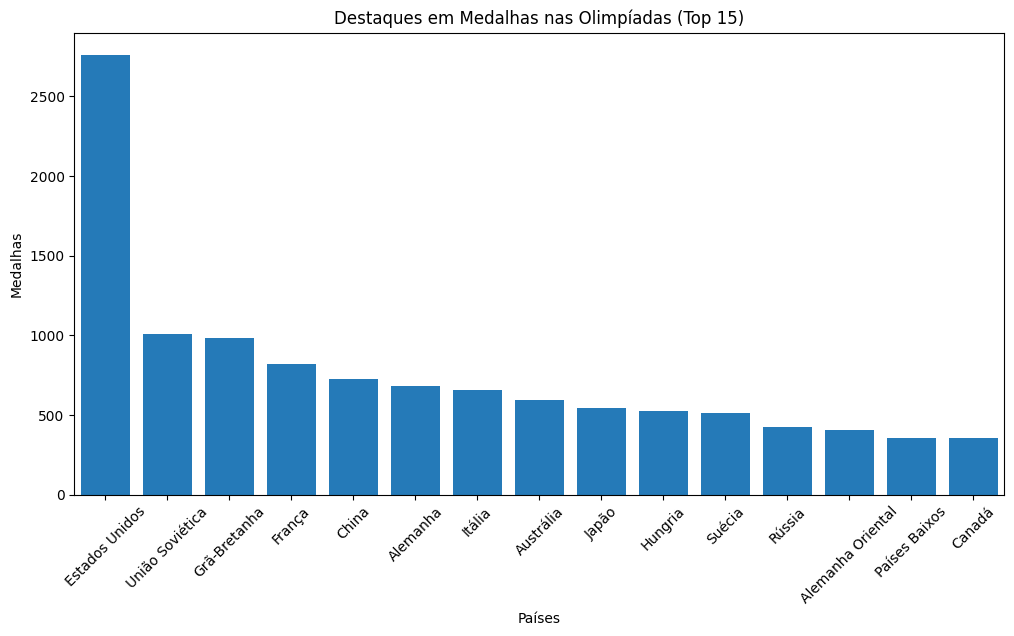

In [32]:
def potencias_olimpicas():
    df_top_olim = df_olimpiadas.nlargest(15, "Total")

    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_top_olim, x='País', y='Total', hue= "País", palette=["#0c7ed0"], legend= False)
    plt.xlabel("Países")
    plt.ylabel("Medalhas")
    plt.xticks(rotation=45)
    plt.title('Destaques em Medalhas nas Olimpíadas (Top 15)')
    plt.show()

potencias_olimpicas()

C:\Users\ednal\AppData\Local\Temp\ipykernel_22620\1449674887.py:5: UserWarning: 
The palette list has fewer values (1) than needed (15) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=df_top_para, x='País', y='Total', hue= "País", palette=["#8ED1EB"], legend= False)


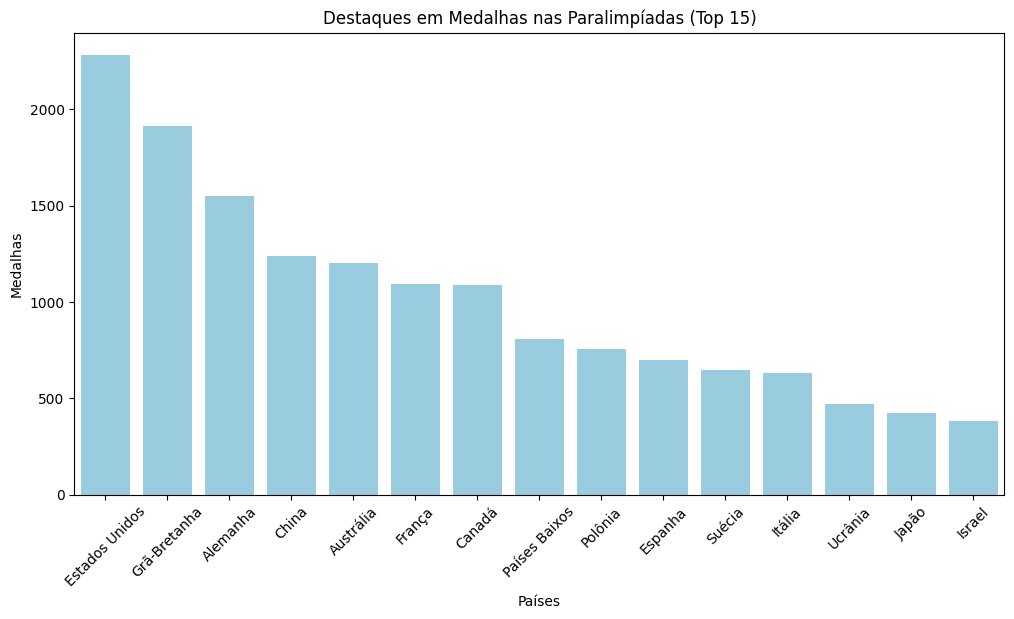

In [33]:
def potencias_paralimpicas():
    df_top_para = df_paralimpiadas.nlargest(15, "Total")

    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_top_para, x='País', y='Total', hue= "País", palette=["#8ED1EB"], legend= False)
    plt.xlabel("Países")
    plt.ylabel("Medalhas")
    plt.xticks(rotation=45)
    plt.title('Destaques em Medalhas nas Paralimpíadas (Top 15)')
    plt.show()

potencias_paralimpicas()

In [34]:
df_olimpico_total = df_olimpiadas.sort_values(by= "Total", ascending= False)
df_olimpico_total = df_olimpico_total[['País', 'Total']]
df_olimpico_total = df_olimpico_total.rename(columns={"Total": "Total_Olimpico"})

df_paralimpico_total = df_paralimpiadas.sort_values(by= "Total", ascending= False)
df_paralimpico_total = df_paralimpico_total[['País', 'Total']]
df_paralimpico_total = df_paralimpico_total.rename(columns={"Total": "Total_Paralimpico"})

display(df_olimpico_total.head())
display(df_paralimpico_total.head())

,País,Total_Olimpico
0,Estados Unidos,2762
1,União Soviética,1010
3,Grã-Bretanha,982
4,França,818
2,China,726


,País,Total_Paralimpico
0,Estados Unidos,2283
1,Grã-Bretanha,1914
2,Alemanha,1550
3,China,1237
4,Austrália,1205


In [58]:
df_olim_e_para = pd.merge(df_olimpico_total, df_paralimpico_total, on='País', how='outer')
df_olim_e_para.fillna(0, inplace=True)
df_olim_e_para["Total_Combinado"] = df_olim_e_para["Total_Olimpico"] + df_olim_e_para["Total_Paralimpico"]
df_olim_e_para = df_olim_e_para[df_olim_e_para["Total_Combinado"] > 0]

display(df_olim_e_para.head())

,País,Total_Olimpico,Total_Paralimpico,Total_Combinado
0,Afeganistão,2.0,0.0,2.0
1,Alemanha,685.0,1550.0,2235.0
2,Alemanha Ocidental,204.0,0.0,204.0
3,Alemanha Oriental,409.0,0.0,409.0
4,Angola,0.0,8.0,8.0


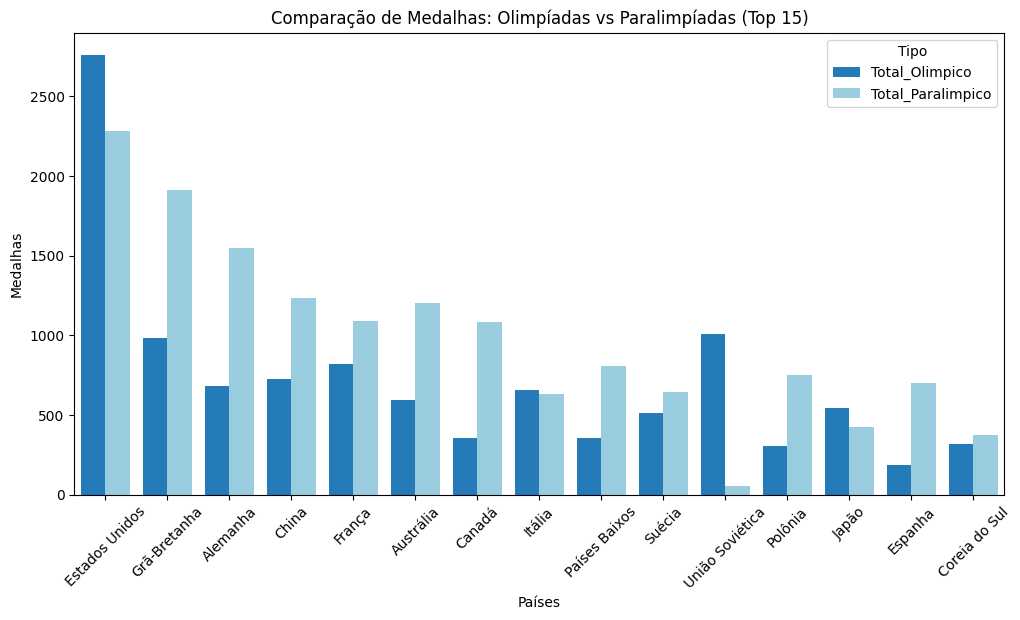

In [39]:
def compara_potencias():
    df_top = df_olim_e_para.nlargest(15, "Total_Combinado")
    df_plot = df_top.melt(id_vars='País', value_vars=['Total_Olimpico', 'Total_Paralimpico'], var_name='Tipo', value_name='Medalhas')

    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_plot, x='País', y='Medalhas', hue='Tipo',  palette=["#0c7ed0", "#8ED1EB"])
    plt.xlabel("Países")
    plt.ylabel("Medalhas")
    plt.xticks(rotation=45)
    plt.title('Comparação de Medalhas: Olimpíadas vs Paralimpíadas (Top 15)')
    plt.show()

compara_potencias()

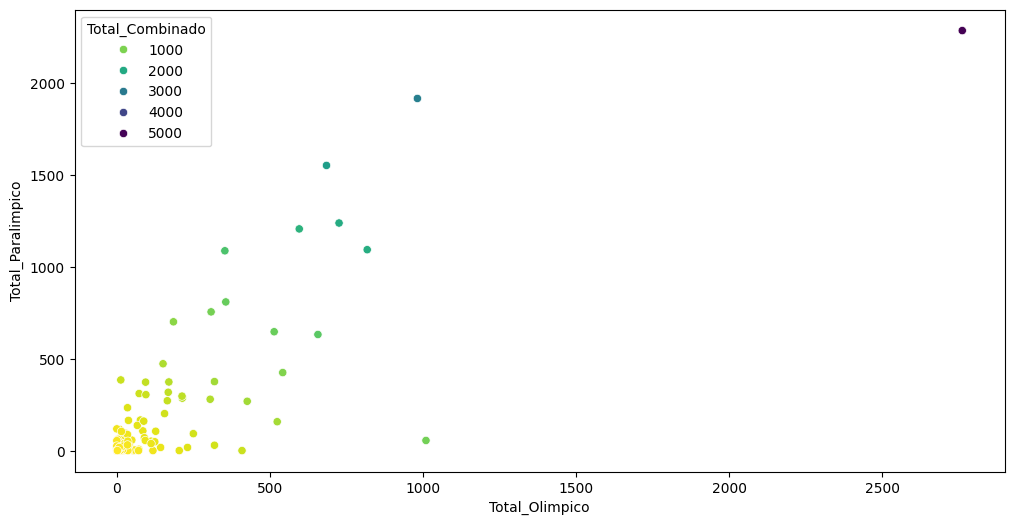

In [73]:
def scatter_plot():

    plt.figure(figsize=(12, 6))
    sns.scatterplot(data= df_olim_e_para, x= "Total_Olimpico", y= "Total_Paralimpico", hue= "Total_Combinado", palette= "viridis_r")
    plt.show()

scatter_plot()

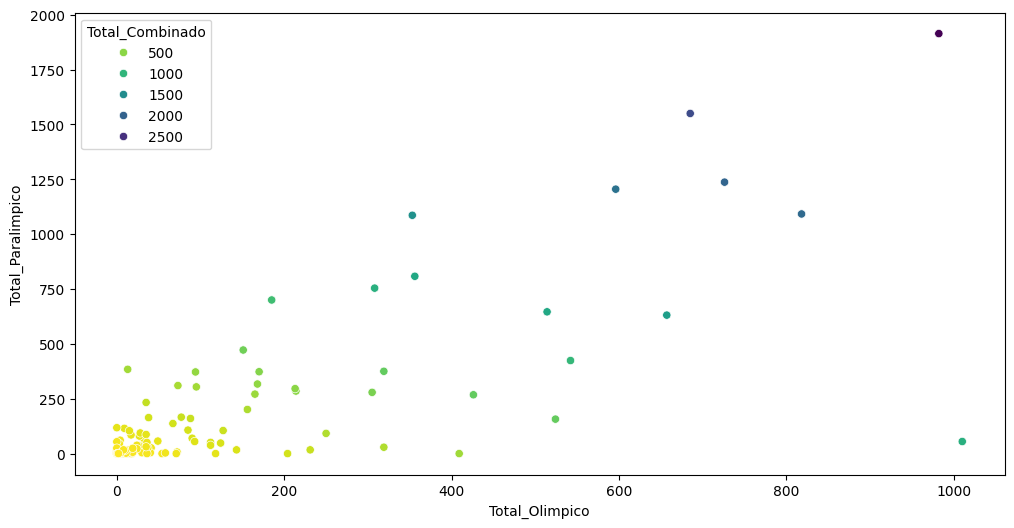

In [72]:
def scatter_plot_sem_eua():
    df_sem_eua = df_olim_e_para[df_olim_e_para["País"] != "Estados Unidos"]

    plt.figure(figsize=(12, 6))
    sns.scatterplot(data= df_sem_eua, x= "Total_Olimpico", y= "Total_Paralimpico", hue= "Total_Combinado", palette= "viridis_r")
    plt.show()

scatter_plot_sem_eua()